# Корпуса: классические модели

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

### Что делаю?

Сравниваю классические модели на тех же $20 000$ train-объектах и $10 000$ hold-out validation-объектах, что и основной MLP sweep.

Модели:
- `Gaussian Naive Bayes`;
- `Logistic Regression`;
- `Random Forest`;
- ~~`LightGBM`~~ _(очень хотел протестировать и бустинг, но у меня он почему-то крашит ядро, не получилось починить к моменту наступления дд...)_.

Для каждой модели гиперпараметры выбираются по 5-fold StratifiedKFold на train, validation остается контролем.

Основная метрика -- `balanced accuracy`; дополнительно считаю `macro-F1`, `macro-precision` и `macro-recall`.


In [54]:
import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torchvision.datasets import FashionMNIST, MNIST


SEED = 143
MAX_ITER = 5_000
TRAIN_SIZE = 20_000
VAL_SIZE = 10_000
N_JOBS = -1
CACHE_DIR = Path.home() / ".cache" / "mlstart_hw03"

cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks" and cwd.parent.name == "hws":
    HWS_DIR = cwd.parent
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
sns.set_theme(style="whitegrid")


## Данные, feature engineering и валидация

Сначала отделяю внешний validation со стратификацией. Только после этого внутри train идет 5-fold CV и подбор параметров -- validation никак не участвует в `GridSearchCV`.

К 784 пикселям добавляю признаки из EDA: они считаются отдельно для каждого изображения и не используют target, leakage нет.


In [55]:
def make_image_features(images):
    X = images.astype(np.float32) / 255.0
    flat = X.reshape(len(X), -1)
    rows = np.arange(28, dtype=np.float32)[None, :, None]
    cols = np.arange(28, dtype=np.float32)[None, None, :]
    mass = X.sum(axis=(1, 2)) + 1e-8
    engineered = np.column_stack([
        X.mean(axis=(1, 2)),
        X.std(axis=(1, 2)),
        (X > 0.2).mean(axis=(1, 2)),
        (X * rows).sum(axis=(1, 2)) / mass / 27.0,
        (X * cols).sum(axis=(1, 2)) / mass / 27.0,
    ]).astype(np.float32)
    return np.column_stack([flat, engineered]).astype(np.float32, copy=False)


def load_split(dataset_class):
    dataset = dataset_class(CACHE_DIR, train=True, download=True)
    y = np.asarray(dataset.targets)
    all_indices = np.arange(len(y))

    train_pool, val_index = train_test_split(
        all_indices,
        test_size=VAL_SIZE,
        stratify=y,
        random_state=SEED,
    )
    train_index, _ = train_test_split(
        train_pool,
        train_size=TRAIN_SIZE,
        stratify=y[train_pool],
        random_state=SEED,
    )

    X_train = make_image_features(dataset.data.numpy()[train_index])
    X_val = make_image_features(dataset.data.numpy()[val_index])
    y_train = y[train_index]
    y_val = y[val_index]
    return X_train, X_val, y_train, y_val, dataset.classes


Учитываю корреляции признаков при feature engineering:

In [56]:
FEATURE_NAMES = [f"pixel_{row}_{col}" for row in range(28) for col in range(28)] + [
    "mean_brightness", "center_y", "center_x"
]  # убираю "pixel_std", "ink_density" из-за высокой их коррелированности


def metric_row(y_true, y_pred):
    return {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def model_spaces():
    return {
        "GaussianNB": (
            GaussianNB(),
            {"var_smoothing": [1e-10, 1e-9, 1e-8]},
        ),
        "Logistic Regression": (
            make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=MAX_ITER, random_state=SEED),
            ),
            {"logisticregression__C": [0.1, 1.0, 10.0]},
        ),
        "Random Forest": (
            RandomForestClassifier(random_state=SEED, n_jobs=N_JOBS),
            {
                "n_estimators": [200, 400],
                "max_features": ["sqrt", 0.5],
            },
        ),
        # "LightGBM": (
        #     LGBMClassifier(
        #         random_state=SEED,
        #         n_jobs=N_JOBS,
        #         verbosity=-1,
        #         max_depth=-1,
        #     ),
        #     {
        #         "n_estimators": [150, 300],
        #         "learning_rate": [0.05, 0.1],
        #         "num_leaves": [31, 63],
        #     },
        # ),
    }


In [57]:
def fit_classical_models(dataset_name, slug, X_train, X_val, y_train, y_val):
    rows = []
    prediction_files = []

    for model_name, (model, param_grid) in model_spaces().items():
        print(dataset_name, model_name)
        search = GridSearchCV(
            model,
            param_grid,
            scoring="balanced_accuracy",
            cv=CV,
            n_jobs=N_JOBS,
            refit=True,
            return_train_score=False,
        )
        started = time.perf_counter()
        search.fit(X_train, y_train)
        elapsed = time.perf_counter() - started

        predictions = search.predict(X_val)
        probabilities = search.predict_proba(X_val)
        metrics = metric_row(y_val, predictions)
        metrics.update({
            "dataset": dataset_name,
            "model": model_name,
            "cv_balanced_accuracy": search.best_score_,
            "fit_time_sec": elapsed,
            "best_params": str(search.best_params_),
        })
        rows.append(metrics)

        if model_name == "Random Forest":
            feature_names = [
                f"feature_{i}"
                for i in range(X_train.shape[1])
            ]

            importance = pd.DataFrame({
                "feature": feature_names,
                "importance": search.best_estimator_.feature_importances_,
            }).sort_values("importance", ascending=False)

            importance.to_csv(
                OUTPUT_DIR / f"{slug}_random_forest_feature_importance.csv",
                index=False,
            )

            top = importance.head(25).sort_values("importance")

            plt.figure(figsize=(9, 7))
            plt.barh(top["feature"], top["importance"])
            plt.xlabel("Random Forest feature importance")
            plt.title(f"{dataset_name} -- Random Forest feature importance, top 25")
            plt.tight_layout()
            plt.savefig(
                OUTPUT_DIR / f"{slug}_random_forest_feature_importance.png",
                dpi=170,
                bbox_inches="tight",
            )
            plt.show()

        # if model_name == "LightGBM":
        #     importance = pd.DataFrame({
        #         "feature": FEATURE_NAMES,
        #         "importance": search.best_estimator_.feature_importances_,
        #     }).sort_values("importance", ascending=False)
        #     importance.to_csv(OUTPUT_DIR / f"{slug}_lightgbm_feature_importance.csv", index=False)

        #     top = importance.head(25).sort_values("importance")
        #     plt.figure(figsize=(9, 7))
        #     plt.barh(top.feature, top.importance)
        #     plt.xlabel("LightGBM split importance")
        #     plt.title(f"{dataset_name} -- LightGBM feature importance, top 25")
        #     plt.tight_layout()
        #     plt.savefig(OUTPUT_DIR / f"{slug}_lightgbm_feature_importance.png", dpi=170, bbox_inches="tight")
        #     plt.show()

        filename = OUTPUT_DIR / f"{slug}_{model_name.lower().replace(' ', '_')}_validation_predictions.npz"
        np.savez_compressed(filename, y_true=y_val, y_pred=predictions, probabilities=probabilities)
        prediction_files.append(filename)

        del search, predictions, probabilities
        gc.collect()

    results = pd.DataFrame(rows).sort_values("balanced_accuracy", ascending=False).reset_index(drop=True)
    results.to_csv(OUTPUT_DIR / f"{slug}_classical_results.csv", index=False)
    return results, prediction_files


## MNIST


MNIST GaussianNB
MNIST Logistic Regression
MNIST Random Forest


/Users/pinta/Dev/mlStart/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pinta/Dev/mlStart/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pinta/Dev/mlStart/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pinta/Dev/mlStart/.venv/lib/python3.14/sit

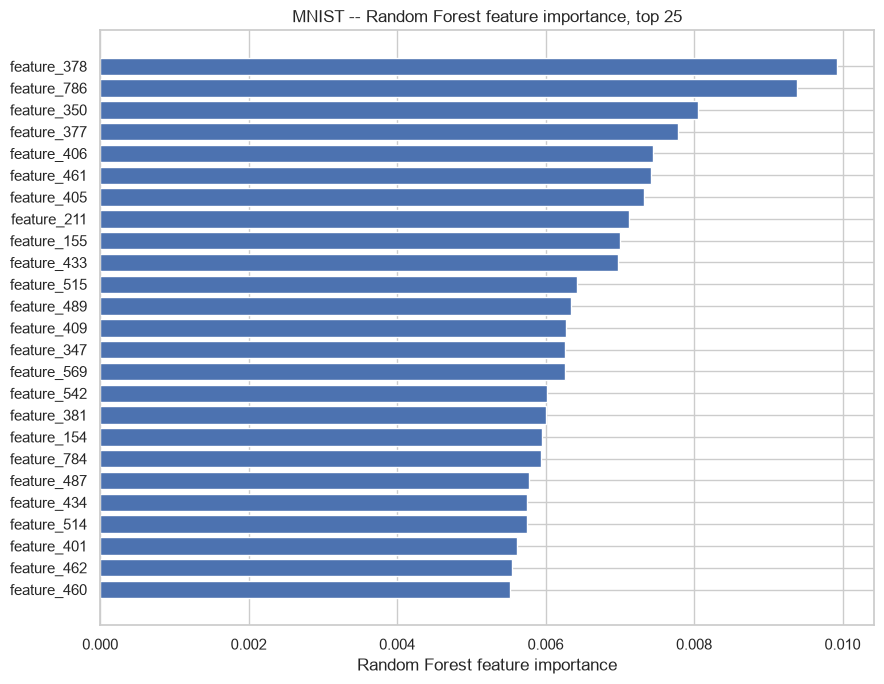

,balanced_accuracy,macro_f1,macro_precision,macro_recall,dataset,model,cv_balanced_accuracy,fit_time_sec,best_params
0,0.957023,0.957068,0.957162,0.957023,MNIST,Random Forest,0.956962,167.981249,"{'max_features': 'sqrt', 'n_estimators': 400}"
1,0.907715,0.907542,0.907541,0.907715,MNIST,Logistic Regression,0.905889,3.413916,{'logisticregression__C': 0.1}
2,0.566727,0.528831,0.660328,0.566727,MNIST,GaussianNB,0.571372,3.949280,{'var_smoothing': 1e-08}


In [58]:
X_train, X_val, y_train, y_val, mnist_classes = load_split(MNIST)
mnist_results, mnist_prediction_files = fit_classical_models("MNIST", "mnist", X_train, X_val, y_train, y_val)
mnist_results


## Feature importance

Для двух древовидных моделей отдельно смотрю встроенные feature importance.

У `Random Forest` это среднее уменьшение impurity по всем деревьям ансамбля. У LightGBM используется split importance. Эти величины напрямую между моделями не сравниваю — здесь интересен прежде всего порядок признаков внутри каждой модели.

_Для изображений особенно интересно, окажутся ли наверху конкретные пиксели или добавленные вручную признаки `mean_brightness`, `pixel_std`, `ink_density`, `center_x`, `center_y`..._

**ОКАЗАЛИСЬ.** Признаки в выводе безымянны _(исправлю)_, но их порядковые номера хранят позицию своего пикселя, соответственно нас интересуют признаки с номерами большими, чем $28 \cdot 28 = 784$, а у нас топ-2 -- `feature_786`, т.е. `center_y`.

In [59]:
def plot_model_metrics(results, dataset_name, slug):
    metrics = ["balanced_accuracy", "macro_f1", "macro_precision", "macro_recall"]
    plot_data = results.melt(id_vars="model", value_vars=metrics, var_name="metric", value_name="score")
    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_data, x="model", y="score", hue="metric")
    plt.ylim(0, 1)
    plt.title(f"{dataset_name} -- validation metrics")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{slug}_classical_metrics.png", dpi=170, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.bar(results.model, results.fit_time_sec)
    plt.ylabel("Seconds")
    plt.title(f"{dataset_name} -- fit time incl. 5-fold GridSearchCV")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{slug}_classical_fit_time.png", dpi=170, bbox_inches="tight")
    plt.show()

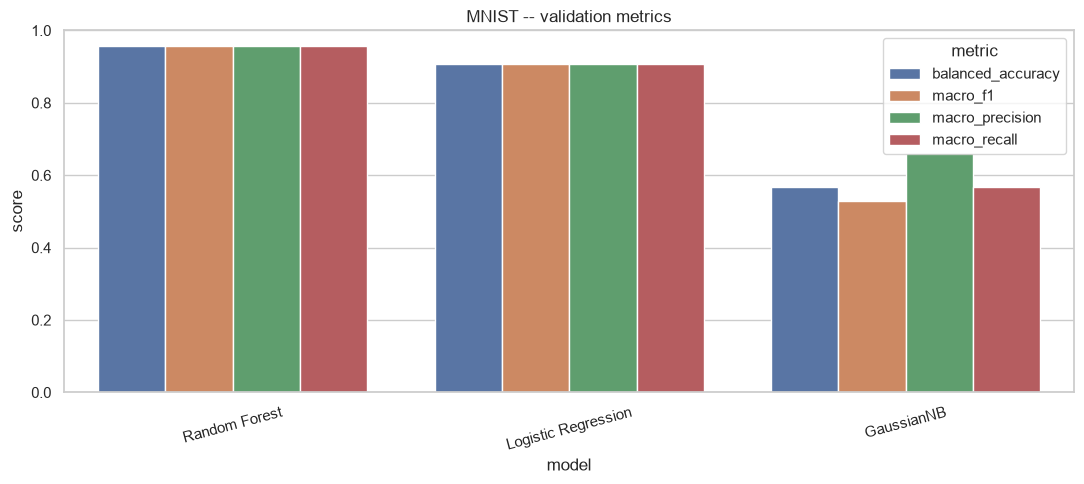

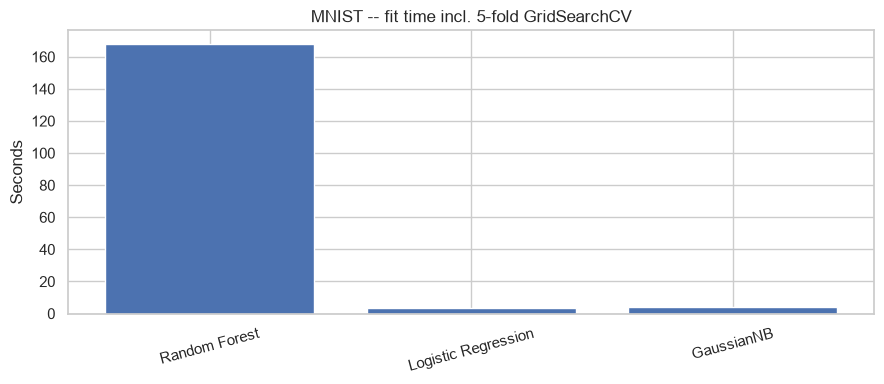

In [60]:
plot_model_metrics(mnist_results, "MNIST", "mnist")

**Выводы ожидаемы**: `RF` оказался лучшим по качеству, но оказался более требовательным к ресурсам (ансамбль все-таки), `GNB` -- самый простой, но и метрики не впечатляют, `LR` -- золотая середина.

In [61]:
def load_predictions(path):
    data = np.load(path)
    return data["y_true"], data["y_pred"], data["probabilities"]


def top_confusions(y_true, y_pred, class_names, n=8):
    cm = confusion_matrix(y_true, y_pred)
    totals = cm.sum(axis=1)
    rows = []
    for true_cls in range(len(class_names)):
        for pred_cls in range(len(class_names)):
            if true_cls != pred_cls and cm[true_cls, pred_cls] > 0:
                rows.append({
                    "true": class_names[true_cls],
                    "predicted": class_names[pred_cls],
                    "count": int(cm[true_cls, pred_cls]),
                    "share_of_true_class": cm[true_cls, pred_cls] / totals[true_cls],
                })
    return pd.DataFrame(rows).sort_values(["count", "share_of_true_class"], ascending=False).head(n)


def plot_best_confusion(results, slug, class_names):
    best_model = results.iloc[0].model
    path = OUTPUT_DIR / f"{slug}_{best_model.lower().replace(' ', '_')}_validation_predictions.npz"
    y_true, y_pred, _ = load_predictions(path)
    cm = confusion_matrix(y_true, y_pred, normalize="true")

    plt.figure(figsize=(11, 9))
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={"size": 8}, vmin=0, vmax=1,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{slug} -- {best_model}, normalized validation confusion matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{slug}_best_classical_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.show()
    return top_confusions(y_true, y_pred, class_names)


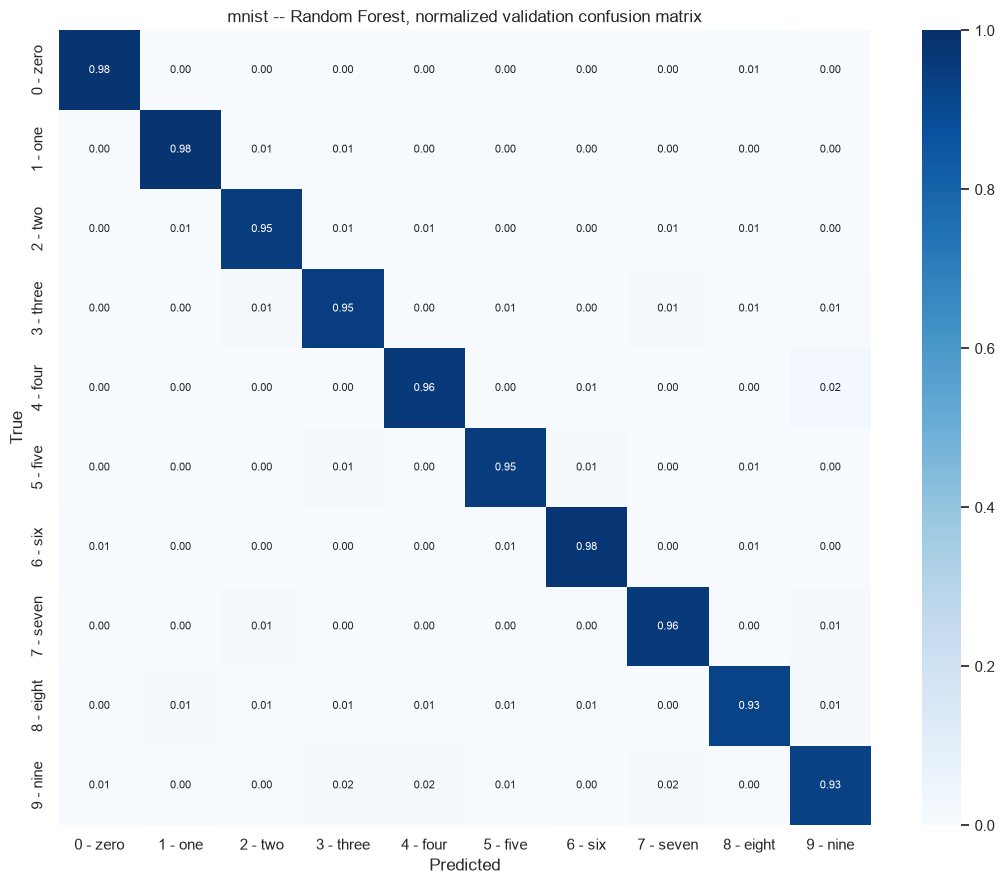

,true,predicted,count,share_of_true_class
33,4 - four,9 - nine,20,0.020534
64,9 - nine,4 - four,16,0.016129
63,9 - nine,3 - three,15,0.015121
67,9 - nine,7 - seven,15,0.015121
21,3 - three,2 - two,15,0.014677
60,8 - eight,9 - nine,14,0.014359
48,7 - seven,2 - two,14,0.013410
51,7 - seven,9 - nine,14,0.013410


In [62]:
mnist_classical_errors = plot_best_confusion(mnist_results, "mnist", mnist_classes)
mnist_classical_errors

## Fashion-MNIST


Fashion-MNIST GaussianNB
Fashion-MNIST Logistic Regression
Fashion-MNIST Random Forest


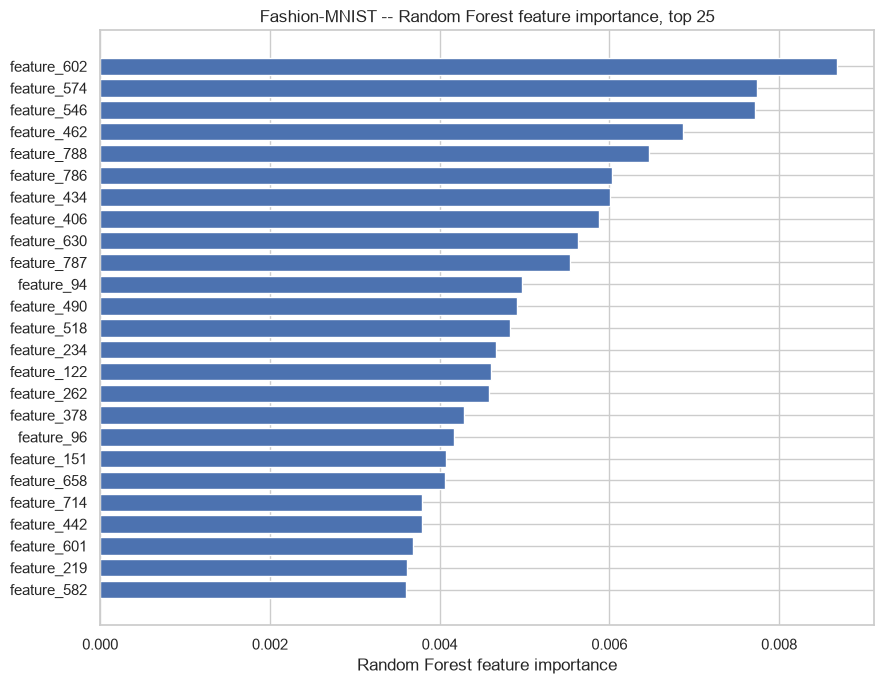

,balanced_accuracy,macro_f1,macro_precision,macro_recall,dataset,model,cv_balanced_accuracy,fit_time_sec,best_params
0,0.8735,0.872230,0.872515,0.8735,Fashion-MNIST,Random Forest,0.87320,436.831882,"{'max_features': 'sqrt', 'n_estimators': 400}"
1,0.8467,0.846463,0.846504,0.8467,Fashion-MNIST,Logistic Regression,0.84295,12.929828,{'logisticregression__C': 0.1}
2,0.6180,0.589195,0.669816,0.6180,Fashion-MNIST,GaussianNB,0.59710,0.615683,{'var_smoothing': 1e-08}


In [63]:
del X_train, X_val, y_train, y_val
gc.collect()

X_train, X_val, y_train, y_val, fashion_classes = load_split(FashionMNIST)
fashion_results, fashion_prediction_files = fit_classical_models("Fashion-MNIST", "fashion", X_train, X_val, y_train, y_val)
fashion_results


## Feature importance

Для двух древовидных моделей отдельно смотрю встроенные feature importance.

У `Random Forest` это среднее уменьшение impurity по всем деревьям ансамбля. У LightGBM используется split importance. Эти величины напрямую между моделями не сравниваю — здесь интересен прежде всего порядок признаков внутри каждой модели.

_Для изображений особенно интересно, окажутся ли наверху конкретные пиксели или добавленные вручную признаки `mean_brightness`, `pixel_std`, `ink_density`, `center_x`, `center_y`..._

**ОКАЗАЛИСЬ.** Признаки в выводе безымянны _(исправлю)_, но их порядковые номера хранят позицию своего пикселя, соответственно нас интересуют признаки с номерами большими, чем $28 \cdot 28 = 784$, а у нас топ-2 -- `feature_786`, т.е. `center_y`.

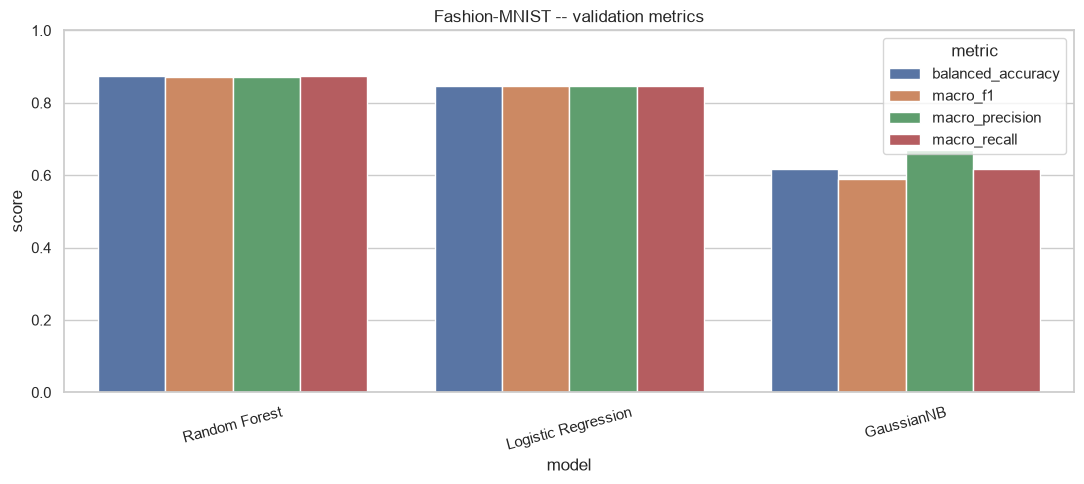

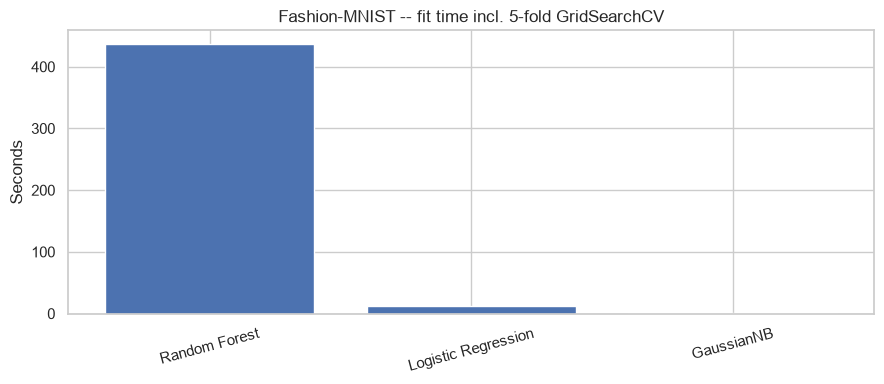

In [64]:
plot_model_metrics(fashion_results, "Fashion-MNIST", "fashion")

Ситуация схожа с числами.

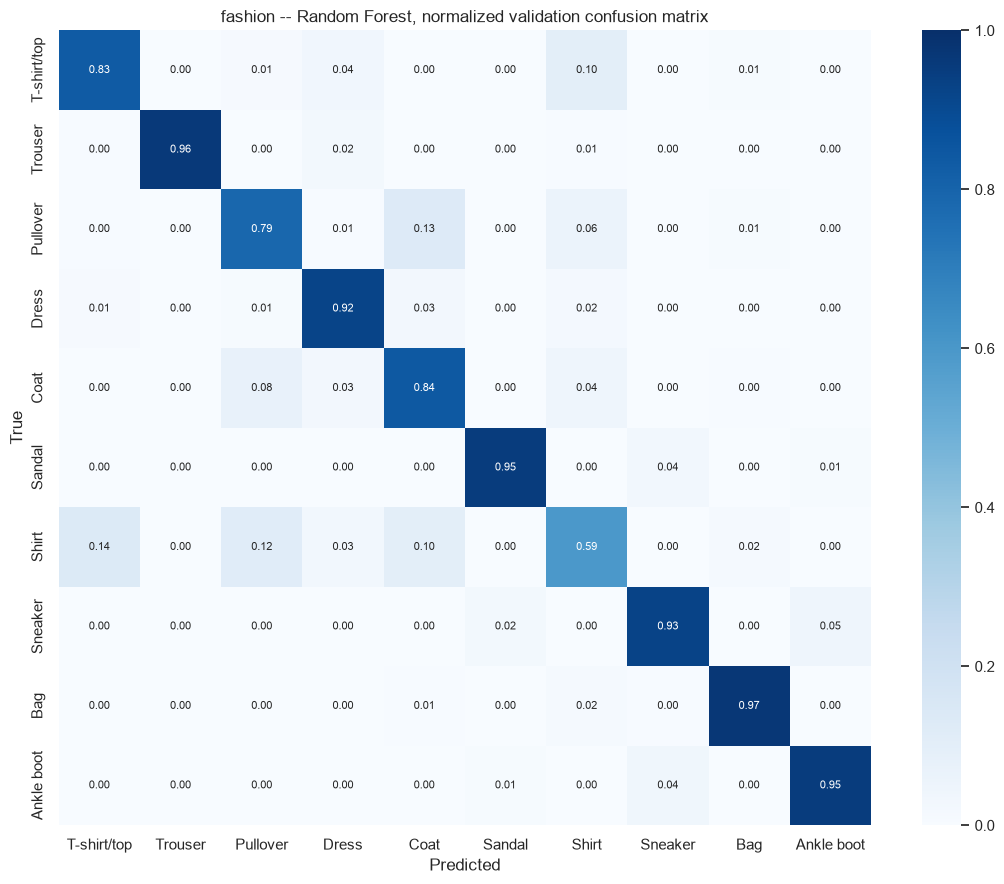

,true,predicted,count,share_of_true_class
33,Shirt,T-shirt/top,135,0.135
14,Pullover,Coat,130,0.130
35,Shirt,Pullover,115,0.115
37,Shirt,Coat,105,0.105
5,T-shirt/top,Shirt,102,0.102
25,Coat,Pullover,78,0.078
15,Pullover,Shirt,61,0.061
41,Sneaker,Ankle boot,48,0.048


In [65]:
fashion_classical_errors = plot_best_confusion(fashion_results, "fashion", fashion_classes)
fashion_classical_errors

Тут все еще хорошее качество предсказаний, но больше ошибок, чем с числами. 

## Анализ ошибок классики

Как и у MLP, смотрю не только на метрики, но и на топ классов, которые модель путает. 

А это -- `Shirt / T-shirt/top / Pullover / Coat`, это согласуется с EDA: модели путаются там, где сами средние силуэты близки.

У `MNIST` же все хорошо.


## Сохраняю подробную таблицу сравнения с MLP

Ее можно посмотреть [тут](/hws/output/model_comparison.csv), `MLP` в итоге оказалась чуть впереди `RF`'а.

,dataset,model,balanced_accuracy,macro_f1,macro_precision,macro_recall,fit_time_sec
0,Fashion-MNIST,MLP,0.878200,0.878856,0.881758,0.878200,11.588034
1,Fashion-MNIST,Random Forest,0.873500,0.872230,0.872515,0.873500,436.831882
2,Fashion-MNIST,Logistic Regression,0.846700,0.846463,0.846504,0.846700,12.929828
3,Fashion-MNIST,GaussianNB,0.618000,0.589195,0.669816,0.618000,0.615683
4,MNIST,MLP,0.967103,0.967164,0.967386,0.967103,11.978526
5,MNIST,Random Forest,0.957023,0.957068,0.957162,0.957023,167.981249
6,MNIST,Logistic Regression,0.907715,0.907542,0.907541,0.907715,3.413916
7,MNIST,GaussianNB,0.566727,0.528831,0.660328,0.566727,3.949280


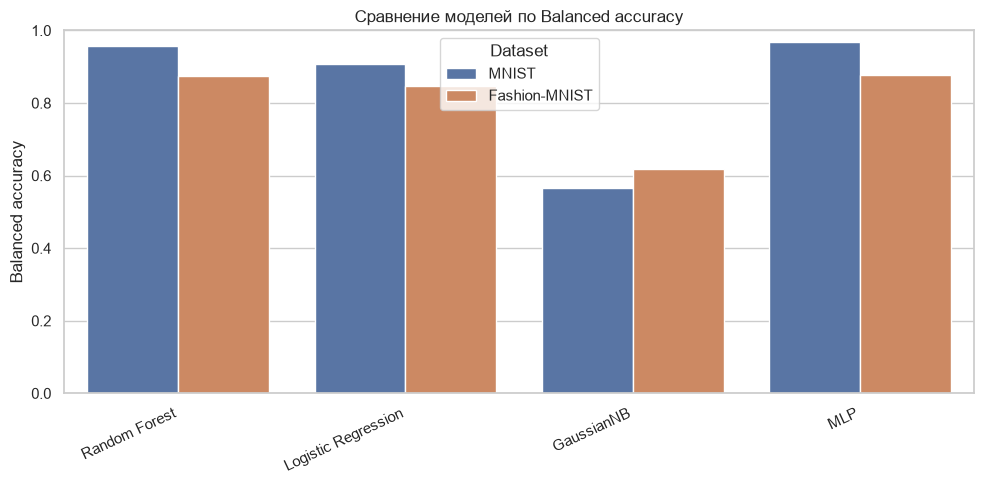

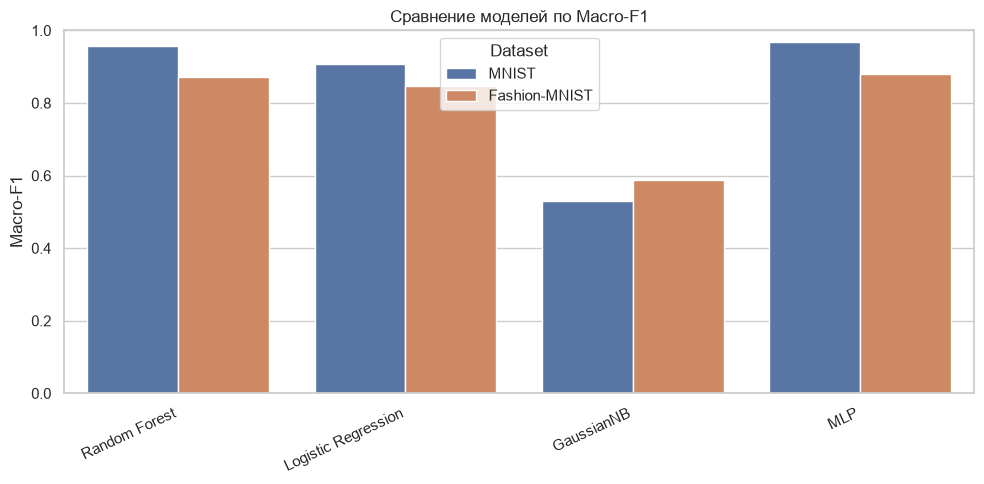

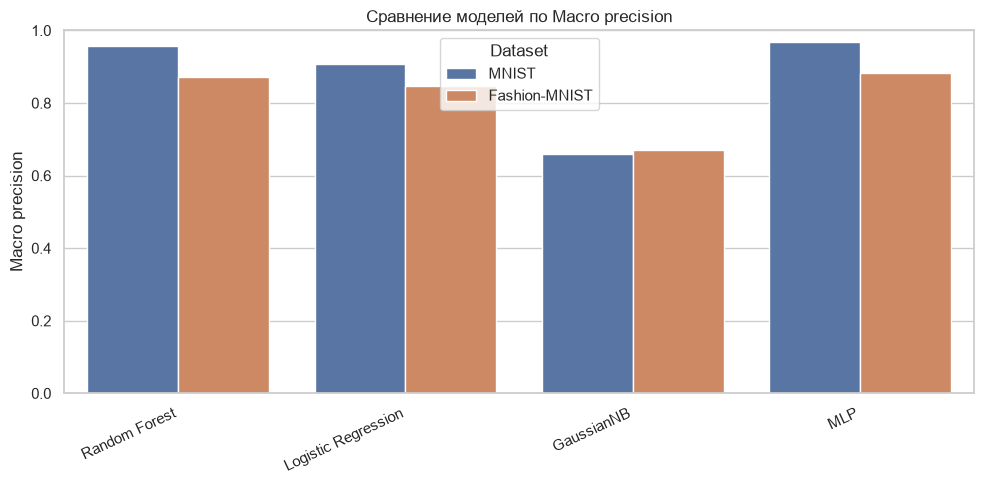

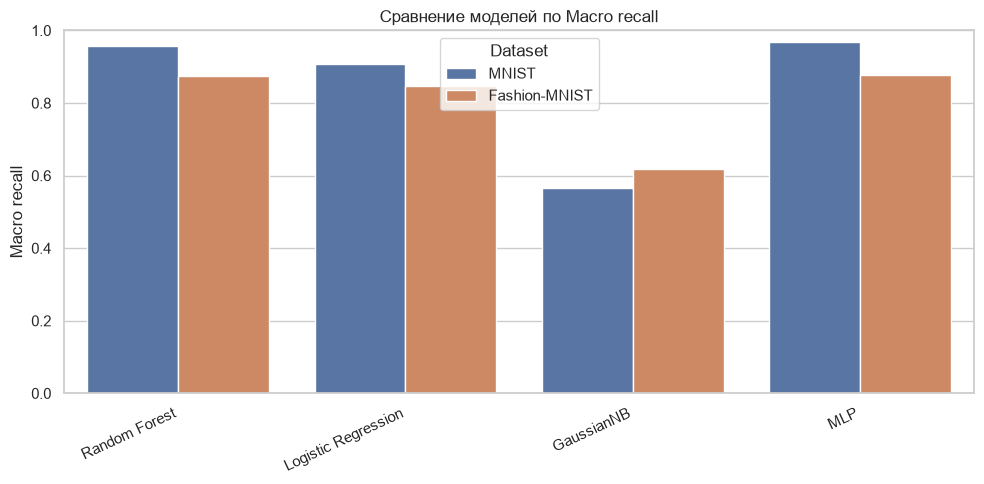

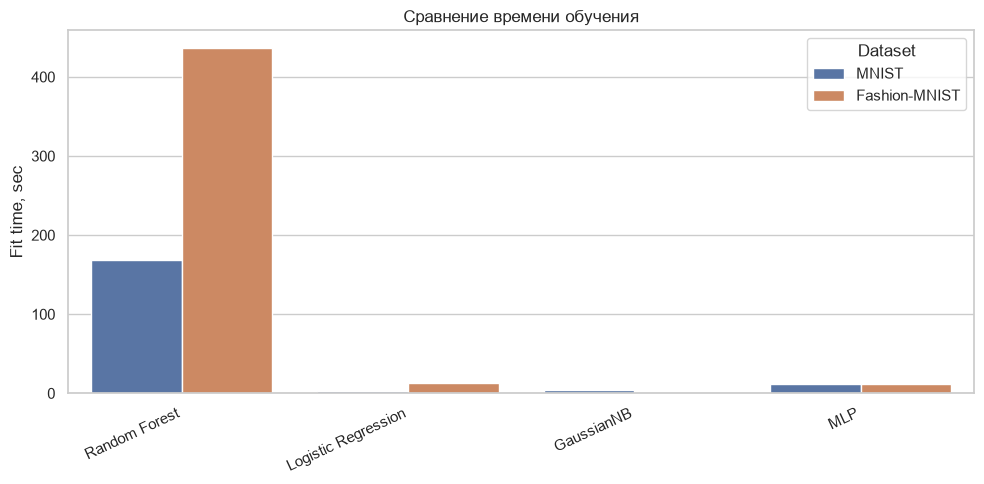

In [66]:
mnist_mlp_path = OUTPUT_DIR / "mnist_mlp_validation_results.csv"
fashion_mlp_path = OUTPUT_DIR / "fashion_mlp_validation_results.csv"

if mnist_mlp_path.exists() and fashion_mlp_path.exists():
    mlp_validation = pd.concat([
        pd.read_csv(mnist_mlp_path),
        pd.read_csv(fashion_mlp_path),
    ], ignore_index=True)

    classical = pd.concat([mnist_results, fashion_results], ignore_index=True)
    classical = classical[[
        "dataset", "model", "balanced_accuracy", "macro_f1",
        "macro_precision", "macro_recall", "fit_time_sec"
    ]]

    model_comparison = pd.concat([classical, mlp_validation], ignore_index=True)

    model_comparison = model_comparison[[
        "dataset", "model", "balanced_accuracy", "macro_f1",
        "macro_precision", "macro_recall", "fit_time_sec"
    ]]

    model_comparison.to_csv(
        OUTPUT_DIR / "model_comparison.csv",
        index=False,
    )

    display(
        model_comparison
        .sort_values(
            ["dataset", "balanced_accuracy"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    metrics = [
        ("balanced_accuracy", "Balanced accuracy"),
        ("macro_f1", "Macro-F1"),
        ("macro_precision", "Macro precision"),
        ("macro_recall", "Macro recall"),
    ]

    for metric, label in metrics:
        plt.figure(figsize=(10, 5))

        sns.barplot(
            data=model_comparison,
            x="model",
            y=metric,
            hue="dataset",
        )

        plt.xlabel("")
        plt.ylabel(label)
        plt.title(f"Сравнение моделей по {label}")
        plt.ylim(0, 1)
        plt.xticks(rotation=25, ha="right")
        plt.legend(title="Dataset")
        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR / f"model_comparison_{metric}.png",
            dpi=170,
            bbox_inches="tight",
        )

        plt.show()

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=model_comparison,
        x="model",
        y="fit_time_sec",
        hue="dataset",
    )

    plt.xlabel("")
    plt.ylabel("Fit time, sec")
    plt.title("Сравнение времени обучения")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Dataset")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "model_comparison_fit_time.png",
        dpi=170,
        bbox_inches="tight",
    )

    plt.show()

else:
    print("Сначала выполните 01_MLP_architecture.ipynb")


## Выводы

- классический ML оказался сопоставим по качеству с `MLP` -- связываю это с простотой задачи;
- из протестированных моделей лучше всего проявил себя `Random Forest`, однако он и самый тяжелый из них (даже `MLP` оказался легче);
- по Feature Importance можно судить, какие из признаков наиболее важны, в их топе есть в том числе и сгенерированные мной!
